# Projeto AGEMC — Predição de Churn

Este notebook reúne o desenvolvimento do projeto da disciplina de Pensamento Analítico de Dados, seguindo o processo **AGEMC**:

- **A — Ask an interesting question**
- **G — Get the data**
- **E — Explore the data**
- **M — Model the data**
- **C — Communicate and visualize the results**

Neste primeiro momento, o notebook contém apenas as três primeiras etapas: **Ask**, **Get** e **Explore**. A originalidade do projeto será introduzida futuramente na etapa **Model**.

## Contexto do projeto

O Projeto FMF escolhido é uma aplicação de aprendizado de máquina para **predição de churn de clientes de telecomunicações**. O problema consiste em prever se um cliente irá cancelar o serviço a partir de características de uso, planos contratados e interações com atendimento.

No nosso projeto, as etapas **Ask**, **Get** e **Explore** seguem o mesmo caminho do Projeto FMF. A contribuição original será aplicada posteriormente na etapa **Model**, e a etapa **Communicate** será afetada pelos resultados dessa modelagem.

## Preparação do ambiente

As células abaixo carregam as bibliotecas, localizam o arquivo de dados e configuram opções básicas de visualização.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "CustomerChurnData.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "CustomerChurnData.csv"
DATA_PATH

WindowsPath('C:/Users/tbail/OneDrive/Documentos/UFG/PAD/data/CustomerChurnData.csv')

# A — Ask an Interesting Question

## Pergunta científica

**É possível prever, a partir do comportamento de uso e do perfil de assinatura de um cliente de telecomunicações, se ele irá cancelar o serviço antes que o cancelamento aconteça?**

O objetivo científico é identificar padrões que diferenciam clientes que cancelam daqueles que permanecem, permitindo construir um modelo capaz de estimar a probabilidade de churn para clientes novos ou ativos.

## O que o projeto deseja prever?

A variável-alvo é `churn`, uma variável binária:

- `False`: o cliente permaneceu;
- `True`: o cliente cancelou.

A previsão dessa variável pode apoiar ações de retenção, como ofertas personalizadas, melhorias no atendimento e priorização de clientes com maior risco de cancelamento.

# G — Get the Data

## Fonte dos dados

O dataset utilizado é o **Churn in Telecom's Dataset**, associado ao caso SyriaTel. A fonte primária é o Kaggle, e o arquivo usado no Projeto FMF também está disponível no repositório da autora de referência.

- Fonte primária: https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset
- Fonte usada como referência FMF: https://github.com/GraceMwende/Customer-Churn
- Arquivo local: `data/CustomerChurnData.csv`

In [2]:
df = pd.read_csv(DATA_PATH)

if df["churn"].dtype == "object":
    df["churn"] = df["churn"].map({"True": True, "False": False})

df.shape

(3333, 21)

In [3]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [4]:
data_quality = pd.DataFrame(
    {
        "indicador": ["linhas", "colunas", "valores ausentes", "linhas duplicadas"],
        "valor": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
    }
)

data_quality

,indicador,valor
0,linhas,3333
1,colunas,21
2,valores ausentes,0
3,linhas duplicadas,0


## Privacidade e seleção inicial

A coluna `phone number` funciona como identificador e deve ser removida antes da modelagem, tanto por baixa utilidade preditiva quanto por boa prática de minimização de dados. As colunas de cobrança também exigem atenção, pois são praticamente derivadas dos minutos correspondentes.

# E — Explore the Data

Nesta etapa, vamos observar a estrutura dos dados, a distribuição da variável-alvo, possíveis padrões associados ao churn e cuidados para a modelagem.

In [5]:
target_summary = (
    df["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="clientes")
)
target_summary["percentual"] = target_summary["clientes"] / len(df) * 100

target_summary

,churn,clientes,percentual
0,False,2850,85.51
1,True,483,14.49


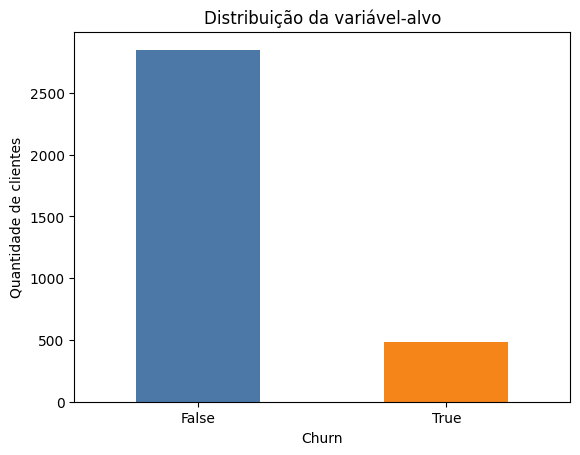

In [6]:
ax = target_summary.set_index("churn")["clientes"].plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("Churn")
ax.set_ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.show()

A variável-alvo é desbalanceada: a maioria dos clientes não cancelou. Esse ponto será importante na modelagem, porque acurácia isolada pode não ser uma boa métrica para avaliar o modelo.

In [7]:
def churn_rate_by(column):
    result = (
        df.groupby(column)["churn"]
        .agg(clientes="count", taxa_churn="mean")
        .reset_index()
    )
    result["taxa_churn_pct"] = result["taxa_churn"] * 100
    return result.drop(columns="taxa_churn")

churn_rate_by("international plan")

,international plan,clientes,taxa_churn_pct
0,no,3010,11.50
1,yes,323,42.41


In [8]:
churn_rate_by("voice mail plan")

,voice mail plan,clientes,taxa_churn_pct
0,no,2411,16.72
1,yes,922,8.68


In [9]:
churn_rate_by("customer service calls")

,customer service calls,clientes,taxa_churn_pct
0,0,697,13.20
1,1,1181,10.33
2,2,759,11.46
3,3,429,10.26
4,4,166,45.78
5,5,66,60.61
6,6,22,63.64
7,7,9,55.56
8,8,2,50.00
9,9,2,100.00


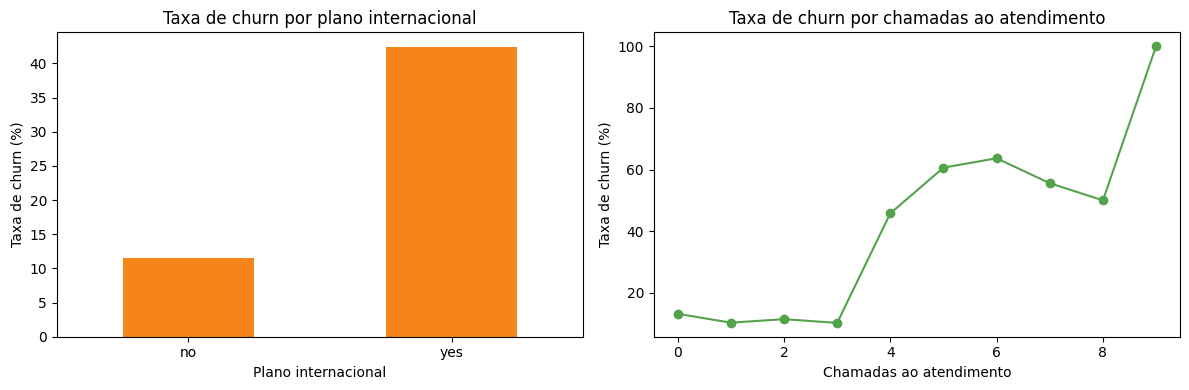

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

intl = churn_rate_by("international plan").set_index("international plan")
intl["taxa_churn_pct"].plot(kind="bar", ax=axes[0], color="#F58518")
axes[0].set_title("Taxa de churn por plano internacional")
axes[0].set_xlabel("Plano internacional")
axes[0].set_ylabel("Taxa de churn (%)")
axes[0].tick_params(axis="x", rotation=0)

service = churn_rate_by("customer service calls").set_index("customer service calls")
service["taxa_churn_pct"].plot(kind="line", marker="o", ax=axes[1], color="#54A24B")
axes[1].set_title("Taxa de churn por chamadas ao atendimento")
axes[1].set_xlabel("Chamadas ao atendimento")
axes[1].set_ylabel("Taxa de churn (%)")

plt.tight_layout()
plt.show()

Dois padrões merecem destaque:

- clientes com plano internacional têm taxa de churn muito maior;
- clientes com 4 ou mais chamadas ao atendimento apresentam aumento forte na taxa de churn.

In [11]:
numeric_focus = [
    "account length",
    "number vmail messages",
    "total day minutes",
    "total eve minutes",
    "total night minutes",
    "total intl minutes",
    "customer service calls",
]

df.groupby("churn")[numeric_focus].mean().T

churn,False,True
account length,100.79,102.66
number vmail messages,8.60,5.12
total day minutes,175.18,206.91
total eve minutes,199.04,212.41
total night minutes,200.13,205.23
total intl minutes,10.16,10.70
customer service calls,1.45,2.23


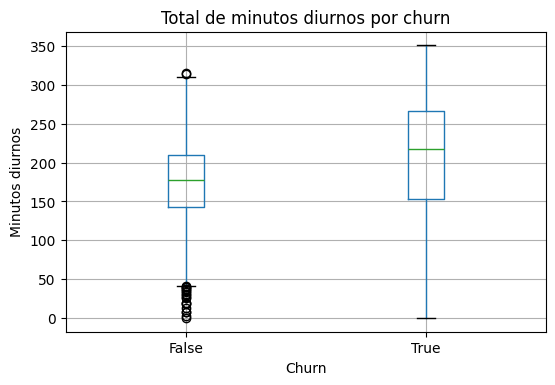

In [12]:
df.boxplot(column="total day minutes", by="churn", figsize=(6, 4))
plt.title("Total de minutos diurnos por churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Minutos diurnos")
plt.show()

In [13]:
numeric_df = df.select_dtypes(include="number").copy()
numeric_df["churn"] = df["churn"].astype(int)

corr_with_churn = (
    numeric_df.corr(numeric_only=True)["churn"]
    .drop("churn")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

corr_with_churn

customer service calls    0.21
total day minutes         0.21
total day charge          0.21
total eve minutes         0.09
total eve charge          0.09
number vmail messages    -0.09
total intl charge         0.07
total intl minutes        0.07
total intl calls         -0.05
total night charge        0.04
total night minutes       0.04
total day calls           0.02
account length            0.02
total eve calls           0.01
area code                 0.01
total night calls         0.01
Name: churn, dtype: float64

In [14]:
charge_pairs = pd.DataFrame(
    [
        {
            "periodo": period,
            "correlacao_minutos_cobranca": df[f"total {period} minutes"].corr(df[f"total {period} charge"]),
        }
        for period in ["day", "eve", "night", "intl"]
    ]
)

charge_pairs

,periodo,correlacao_minutos_cobranca
0,day,1.00
1,eve,1.00
2,night,1.00
3,intl,1.00


## Localização (estado) — teste da hipótese H4

A hipótese **H4** afirma que a localização (`state`) tem pouco poder preditivo isoladamente. Diferente das variáveis anteriores, `state` é categórica com muitas categorias (51), então a correlação linear não é adequada. Para avaliar a associação entre `state` e `churn`, observamos (1) a taxa de churn por estado, (2) o tamanho da amostra em cada grupo e (3) o **teste qui-quadrado de independência**.

In [15]:
state_churn = churn_rate_by("state").sort_values("taxa_churn_pct", ascending=False)

# 5 estados com maior e 5 com menor taxa de churn
pd.concat([state_churn.head(5), state_churn.tail(5)])

,state,clientes,taxa_churn_pct
4,CA,34,26.47
31,NJ,68,26.47
43,TX,72,25.00
20,MD,70,24.29
40,SC,60,23.33
12,IA,44,6.82
45,VA,77,6.49
3,AZ,64,6.25
0,AK,52,5.77
11,HI,53,5.66


In [16]:
churners_por_estado = state_churn["taxa_churn_pct"] / 100 * state_churn["clientes"]

state_sample = pd.DataFrame(
    {
        "indicador": [
            "estados",
            "min clientes/estado",
            "mediana clientes/estado",
            "max clientes/estado",
            "media churners/estado",
        ],
        "valor": [
            f"{state_churn['state'].nunique()}",
            f"{int(state_churn['clientes'].min())}",
            f"{state_churn['clientes'].median():.0f}",
            f"{int(state_churn['clientes'].max())}",
            f"{churners_por_estado.mean():.2f}",
        ],
    }
)

state_sample

,indicador,valor
0,estados,51
1,min clientes/estado,34
2,mediana clientes/estado,65
3,max clientes/estado,106
4,media churners/estado,9.47


In [17]:
from scipy.stats import chi2_contingency

contingencia = pd.crosstab(df["state"], df["churn"])
chi2, p_valor, gl, esperado = chi2_contingency(contingencia)
n = int(contingencia.to_numpy().sum())
cramers_v = (chi2 / (n * (min(contingencia.shape) - 1))) ** 0.5

teste_h4 = pd.DataFrame(
    {
        "indicador": [
            "qui-quadrado (chi2)",
            "graus de liberdade",
            "p-valor",
            "Cramer's V",
            "celulas esperadas < 5",
        ],
        "valor": [
            f"{chi2:.2f}",
            f"{gl}",
            f"{p_valor:.4f}",
            f"{cramers_v:.3f}",
            f"{int((esperado < 5).sum())} de {esperado.size}",
        ],
    }
)

teste_h4

,indicador,valor
0,qui-quadrado (chi2),83.04
1,graus de liberdade,50
2,p-valor,0.0023
3,Cramer's V,0.158
4,celulas esperadas < 5,1 de 102


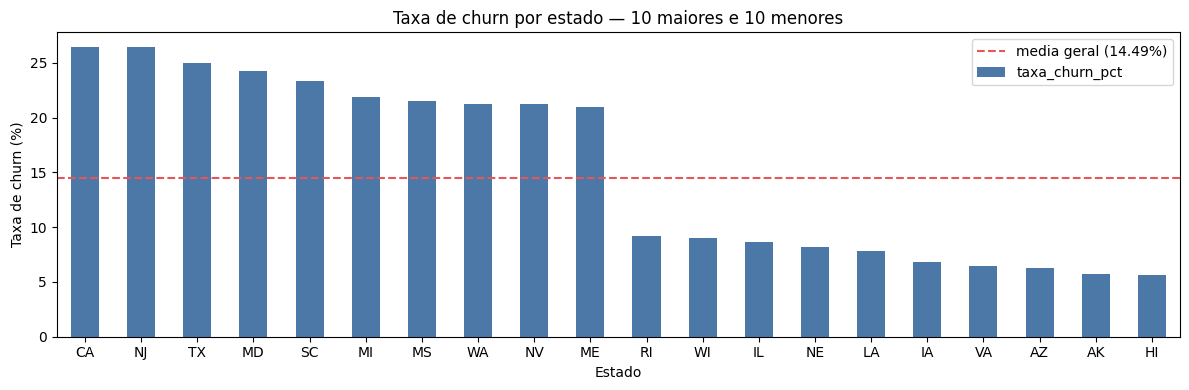

In [18]:
top_bottom = pd.concat([state_churn.head(10), state_churn.tail(10)]).set_index("state")
baseline = df["churn"].mean() * 100

ax = top_bottom["taxa_churn_pct"].plot(kind="bar", figsize=(12, 4), color="#4C78A8")
ax.axhline(baseline, color="#E45756", linestyle="--", label=f"media geral ({baseline:.2f}%)")
ax.set_title("Taxa de churn por estado — 10 maiores e 10 menores")
ax.set_xlabel("Estado")
ax.set_ylabel("Taxa de churn (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

A taxa de churn varia de forma aparente entre estados (de cerca de **5,7%** a **26,5%**), e o teste qui-quadrado indica que essa variação é **estatisticamente significativa** (χ² = 83,04, gl = 50, p = 0,0023), sendo um teste válido (apenas 1 de 102 células com frequência esperada abaixo de 5).

No entanto, o tamanho do efeito é **pequeno** (Cramér's V ≈ 0,16) e cada estado possui poucos registros (mediana de 65 clientes e cerca de 9 churners por estado). Existe, portanto, algum sinal associado à localização, mas ele é **fraco e instável** quando usado isoladamente, além de envolver alta cardinalidade (51 categorias) com risco de overfitting.

Assim, **H4 é refinada**: a localização não é um preditor central como `international plan` ou `customer service calls`, mas também não é puro ruído. Na etapa de modelagem, o estado deve ser usado com cautela — agregado ou descartado — e não como variável principal.

## Conclusões da exploração

A exploração inicial mostra que os dados estão limpos, sem valores ausentes ou duplicados. O principal cuidado é o desbalanceamento da variável-alvo.

As variáveis que mais parecem associadas ao churn nesta etapa são:

- `international plan`;
- `customer service calls`;
- `total day minutes`;
- `voice mail plan`;
- `number vmail messages`.

Também foi observado que as colunas de cobrança são redundantes em relação às colunas de minutos. Na etapa de modelagem, será necessário decidir quais dessas variáveis manter para evitar duplicidade de informação.

A próxima etapa do AGEMC será **M — Model the Data**, onde será introduzida a originalidade do projeto.

# M — Model the Data

Esta é a etapa onde entra a **originalidade** do projeto. Enquanto o Projeto FMF de
referência vai direto para um classificador, nossa contribuição é uma **modelagem
estatisticamente fundamentada**: antes de treinar qualquer modelo, **testamos
formalmente as hipóteses H1–H4** levantadas na exploração. Os resultados desses testes
(significância e tamanho de efeito) é que **guiam a seleção de variáveis** e dão a
**interpretação** do modelo final.

O fluxo da etapa M é:

1. **M.0** — Separação treino/teste do *df* bruto **antes de tudo** (anti-vazamento).
2. **M.1** — Testes de hipótese **somente no treino** (qui-quadrado, Mann-Whitney, ponto-bisserial, Cramér's V).
3. **M.2** — Seleção de variáveis **informada pelos testes** e validada por validação cruzada; codificação ajustada no treino.
4. **M.3** — Modelo *baseline*.
5. **M.4** — Validação cruzada (Logística, Random Forest e RF + SMOTENC) com `StratifiedKFold`.
6. **M.5** — Avaliação no teste *held-out* com limiar escolhido por F1.
7. **M.6** — Interpretação (odds ratios e importância de variáveis) ligada às hipóteses.
8. **M.7** — Conclusões da modelagem.


### Dicionário de variáveis

As colunas usadas na modelagem (nomes originais em inglês) e seus significados:

| coluna (inglês) | significado (português) |
|---|---|
| `churn` | alvo: cliente cancelou o serviço (verdadeiro/falso) |
| `state` | estado (UF) do cliente |
| `account length` | tempo de conta (em dias) |
| `area code` | código de área da linha (categórico nominal) |
| `international plan` | possui plano internacional (sim/não) |
| `voice mail plan` | possui plano de correio de voz (sim/não) |
| `number vmail messages` | número de mensagens de correio de voz |
| `total day minutes` | total de minutos em ligações diurnas |
| `total day calls` | total de ligações diurnas |
| `total eve minutes` | total de minutos em ligações no fim de tarde/noite |
| `total eve calls` | total de ligações no fim de tarde/noite |
| `total night minutes` | total de minutos em ligações na madrugada |
| `total night calls` | total de ligações na madrugada |
| `total intl minutes` | total de minutos em ligações internacionais |
| `total intl calls` | total de ligações internacionais |
| `customer service calls` | número de chamadas ao atendimento |

As cobranças `total * charge` e o identificador `phone number` são descartados na preparação
(M.2) — as primeiras por serem quase perfeitamente redundantes com os minutos; o segundo por
ser identificador sem valor preditivo.


In [19]:
# Bibliotecas da etapa de modelagem
import numpy as np
from scipy import stats
import statsmodels.api as sm

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict,
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score, roc_curve, precision_recall_curve,
)
from imblearn.over_sampling import SMOTENC
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
df.shape


(3333, 21)

### Funções de apresentação

Camada apenas visual: padroniza a saída dos resultados (tabela alinhada, linha-resumo de métricas separadas por ` | ` e linha de decisão). **Não altera nenhum cálculo** — apenas formata o que é exibido.


In [20]:
# === Camada de apresentação: helpers de formatação (não alteram cálculos) ===
def _fmt_valor(v):
    """Formata um valor de forma consistente, sem perder precisão essencial:
    - str: usada tal como veio (permite precisão sob medida quando necessário);
    - int: sem casas decimais;
    - float muito pequeno (|v| < 1e-3, p-values): notação científica .3e;
    - demais floats: 3 casas decimais."""
    if isinstance(v, str):
        return v
    if isinstance(v, bool):
        return str(v)
    if isinstance(v, (int, np.integer)):
        return f"{v}"
    if isinstance(v, (float, np.floating)):
        if v != 0 and abs(v) < 1e-3:
            return f"{v:.3e}"
        return f"{v:.3f}"
    return str(v)


def format_metric_line(metricas: dict) -> str:
    """Junta métricas numa única linha separada por ' | ', preservando a ordem.
    Ex.: {"chi2": 320.78, "p": 9.77e-72, "gl": 1, "Cramér's V": 0.310}
         -> "chi2 = 320.780 | p = 9.773e-72 | gl = 1 | Cramér's V = 0.310" """
    return " | ".join(f"{rotulo} = {_fmt_valor(v)}" for rotulo, v in metricas.items())


def print_resultado(titulo, tabela=None, metricas=None, decisao=None):
    """Bloco de resultado padronizado: título, tabela alinhada (opcional),
    linha-resumo de métricas (opcional) e linha de decisão (opcional)."""
    print(titulo)
    if tabela is not None:
        print(tabela.to_string())
    if metricas is not None:
        print("  " + format_metric_line(metricas))
    if decisao is not None:
        print(f"  decisão: {decisao}")
    print()


## M.0 — Separação treino/teste (anti-vazamento)

Para evitar **vazamento de informação**, dividimos o *df* **bruto** em treino (75%) e teste
(25%) de forma **estratificada** (preservando a proporção de churn) **antes de qualquer
análise**. A partir daqui, **todos os testes de hipótese (M.1) e a seleção de variáveis
(M.2) usam apenas o treino (`df_tr`)**; o conjunto de teste (`df_te`) só é tocado na
avaliação final (M.5). Nenhuma transformação muta o `df` global.


In [21]:
df_tr, df_te = train_test_split(
    df, test_size=0.25, stratify=df["churn"], random_state=RANDOM_STATE
)
print_resultado(
    "Split estratificado treino/teste (df bruto)",
    metricas={
        "treino": df_tr.shape[0],
        "teste": df_te.shape[0],
        "churn treino": df_tr["churn"].mean(),
        "churn teste": df_te["churn"].mean(),
    },
)


Split estratificado treino/teste (df bruto)
  treino = 2499 | teste = 834 | churn treino = 0.145 | churn teste = 0.145



## M.1 — Testes de hipótese

As hipóteses refinadas na etapa Explore eram:

- **H1:** clientes com muitas chamadas ao atendimento têm maior propensão ao churn.
- **H2:** clientes com maior uso diurno apresentam maior taxa de churn.
- **H3:** clientes com plano internacional têm churn bem acima da média.
- **H4:** a localização (estado) pode ter algum sinal.

Para cada hipótese escolhemos o teste adequado ao **tipo de dado**:

| Hipótese | Variável | Tipo | Teste | Tamanho de efeito |
|---|---|---|---|---|
| H1 | `customer service calls` (≥4) | categórica/ordinal | qui-quadrado | Cramér's V + ponto-bisserial |
| H2 | `total day minutes` | numérica | Mann-Whitney U | ponto-bisserial |
| H3 | `international plan` | categórica | qui-quadrado | Cramér's V |
| H4 | `state` | categórica | qui-quadrado | Cramér's V |

Usamos **Mann-Whitney** (não paramétrico) em H2 porque não assumimos normalidade, e a
**correlação ponto-bisserial** para medir o tamanho do efeito entre uma variável binária
(churn) e uma numérica. Adotamos **α = 0,05**. **Todos os testes abaixo rodam somente no
treino (`df_tr`)** — o teste é reservado para a avaliação (M.5). A análise detalhada de
**H4 (estado)** está na **etapa E**; aqui mantemos apenas uma confirmação breve.


In [22]:
# Cramér's V: tamanho de efeito para tabelas de contingência (0 = nenhuma associação)
def cramer_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))


def teste_qui_quadrado(coluna, label, dados=None):
    """Qui-quadrado de `coluna` x churn. Roda no treino por padrão (sem mutar o df)."""
    dados = df_tr if dados is None else dados
    ct = pd.crosstab(dados[coluna], dados["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    decisao = "rejeita H0 (associação significativa)" if p < 0.05 else "não rejeita H0"
    print_resultado(
        f"[{label}] {coluna} x churn",
        tabela=ct,
        metricas={"chi2": chi2, "p": p, "gl": dof, "Cramér's V": cramer_v(ct.values)},
        decisao=decisao,
    )
    return p


# H3 - plano internacional
teste_qui_quadrado("international plan", "H3")
# voice mail plan (achado de proteção observado na exploração)
teste_qui_quadrado("voice mail plan", "extra");


[H3] international plan x churn
churn               False  True 
international plan              
no                   2002    262
yes                   135    100
  chi2 = 162.470 | p = 3.267e-37 | gl = 1 | Cramér's V = 0.255
  decisão: rejeita H0 (associação significativa)

[extra] voice mail plan x churn
churn            False  True 
voice mail plan              
no                1497    306
yes                640     56
  chi2 = 31.579 | p = 1.915e-08 | gl = 1 | Cramér's V = 0.112
  decisão: rejeita H0 (associação significativa)



In [23]:
# H1 - chamadas ao atendimento: binarizamos em >=4 (limiar visto na exploração).
# Construímos uma tabela LOCAL (não muta o df global).
csc_tr = pd.DataFrame({
    "csc_4plus": np.where(df_tr["customer service calls"] >= 4, "4 ou mais", "0 a 3"),
    "churn": df_tr["churn"].to_numpy(),
})
teste_qui_quadrado("csc_4plus", "H1", dados=csc_tr)

# reforço de H1 com a variável contínua: correlação ponto-bisserial (no treino)
churn_int_tr = df_tr["churn"].astype(int)
r_pb, p_pb = stats.pointbiserialr(churn_int_tr, df_tr["customer service calls"])
print_resultado(
    "H1 (contínua) ponto-bisserial: churn x customer service calls",
    metricas={"r": r_pb, "p": p_pb},
)


[H1] csc_4plus x churn
churn      False  True 
csc_4plus              
0 a 3       2041    253
4 ou mais     96    109
  chi2 = 266.401 | p = 6.907e-60 | gl = 1 | Cramér's V = 0.327
  decisão: rejeita H0 (associação significativa)

H1 (contínua) ponto-bisserial: churn x customer service calls
  r = 0.224 | p = 9.582e-30



In [24]:
# H2 - minutos diurnos: Mann-Whitney (não assume normalidade) + ponto-bisserial (no treino)
day_churn = df_tr.loc[df_tr["churn"], "total day minutes"]
day_fiel = df_tr.loc[~df_tr["churn"], "total day minutes"]
u_stat, p_mw = stats.mannwhitneyu(day_churn, day_fiel, alternative="greater")
r_pb, p_pb = stats.pointbiserialr(df_tr["churn"].astype(int), df_tr["total day minutes"])

decisao = "rejeita H0 (churn usa mais minutos diurnos)" if p_mw < 0.05 else "não rejeita H0"
print_resultado(
    "[H2] total day minutes x churn",
    metricas={
        "média churn": day_churn.mean(),
        "média não-churn": day_fiel.mean(),
        "Mann-Whitney U": f"{u_stat:.0f}",
        "p (maior)": p_mw,
        "r ponto-bisserial": r_pb,
        "p (r)": p_pb,
    },
    decisao=decisao,
)


[H2] total day minutes x churn
  média churn = 205.094 | média não-churn = 175.421 | Mann-Whitney U = 488538 | p (maior) = 5.544e-16 | r ponto-bisserial = 0.193 | p (r) = 2.568e-22
  decisão: rejeita H0 (churn usa mais minutos diurnos)



In [25]:
# H4 - estado: qui-quadrado CONFIRMATÓRIO no treino (muitas categorias, células pequenas).
# A análise detalhada de H4 está na etapa E — aqui apenas confirmamos o sinal, sem duplicar.
p_state = teste_qui_quadrado("state", "H4")
print_resultado(
    "Nota sobre H4",
    decisao="análise detalhada do estado (taxa por UF, mapa) está na etapa E",
)


[H4] state x churn
churn  False  True 
state              
AK        37      3
AL        54      5
AR        35      7
AZ        46      3
CA        18      7
CO        46      7
CT        45     11
DC        40      2
DE        39      8
FL        48      6
GA        27      7
HI        39      1
IA        29      3
ID        49      9
IL        41      5
IN        43      9
KS        44     10
KY        41      6
LA        37      4
MA        43      7
MD        38     14
ME        43      9
MI        37     11
MN        50     11
MO        44      7
MS        38     10
MT        42     11
NC        43      9
ND        38      4
NE        43      3
NH        39      6
NJ        39     12
NM        41      6
NV        40     12
NY        49     12
OH        46      8
OK        44      5
OR        45      6
PA        26      7
RI        41      4
SC        33     12
SD        40      6
TN        37      3
TX        42     11
UT        48      8
VA        51      3
VT        45      3
W

In [26]:
# Ranking de tamanho de efeito (ponto-bisserial) de TODAS as numéricas com churn (no treino).
# Este ranking ALIMENTA a seleção de variáveis do M.2.
churn_int_tr = df_tr["churn"].astype(int)
num_cols = df_tr.select_dtypes("number").columns
ranking = pd.DataFrame(
    [(c, *stats.pointbiserialr(churn_int_tr, df_tr[c])) for c in num_cols],
    columns=["variável", "r_ponto_bisserial", "p_valor"],
).sort_values("r_ponto_bisserial", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
ranking


,variável,r_ponto_bisserial,p_valor
0,customer service calls,0.22,0.00
1,total day charge,0.19,0.00
2,total day minutes,0.19,0.00
3,number vmail messages,-0.10,0.00
4,total eve minutes,0.09,0.00
5,total eve charge,0.09,0.00
6,total intl calls,-0.07,0.00
7,total intl charge,0.07,0.00
8,total intl minutes,0.07,0.00
9,total day calls,0.02,0.22


**Leitura dos testes:** os qui-quadrados de **H1** (chamadas ao atendimento ≥ 4) e **H3**
(plano internacional) e o Mann-Whitney de **H2** (minutos diurnos) são **estatisticamente
significativos** (ver `p` impresso acima), com tamanhos de efeito relevantes (Cramér's V /
ponto-bisserial). O `voice mail plan` aparece como fator **protetor**. O ranking
ponto-bisserial mostra que `customer service calls` e `total day minutes` lideram entre as
numéricas, enquanto `account length` e boa parte das contagens de ligações têm `r` próximo
de zero — **sem sinal** (a lista exata de mantidas/descartadas é impressa na seleção de M.2).
**H4 (estado)** costuma sair significativa, porém com **efeito pequeno e células esparsas**
(sinal fraco, como antecipado).

**Regra de seleção (M.1 → M.2):** levaremos para o modelo as variáveis com **associação
significativa e tamanho de efeito relevante** e **descartaremos as sem sinal** — decisão que
será **validada por validação cruzada** no próximo passo.


## M.2 — Seleção de variáveis informada pelos testes

Aqui a originalidade se concretiza: a seleção de variáveis **deriva diretamente dos testes
de M.1** (calculados no treino). As decisões de preparação:

- **removemos `phone number`** (identificador, sem valor preditivo e por minimização de dados);
- **removemos as cobranças `total * charge`**, quase perfeitamente correlacionadas com os
  minutos (r ≈ 1,0) — usar ambas seria redundância/colinearidade;
- **mantemos as numéricas com sinal** no ranking ponto-bisserial (|r| acima de um limiar e
  p < 0,05) e **descartamos as sem sinal** (`account length`, ligações `*calls`);
- **`area code` é descartado**: no ranking de M.1 tem efeito ≈ 0 e p > 0,05, caindo pelo mesmo
  critério das numéricas sem sinal (antes era mantido como one-hot sem justificativa);
- **codificação ajustada no treino** via `ColumnTransformer` + `OneHotEncoder(drop="if_binary")`
  para as binárias `international plan` e `voice mail plan`, alinhando o teste por dentro do
  *pipeline* (sem vazamento);
- **`state`** tem sinal fraco (H4): comparamos **manter vs. dropar** os *dummies* por métrica
  de validação cruzada (PR-AUC/F1) e ficamos com a melhor opção.

A seleção é então **validada por validação cruzada**: se a versão enxuta não piorar as
métricas frente ao conjunto completo, ela é adotada; caso contrário, recuamos.


In [27]:
# --- Conjuntos de colunas a partir dos resultados dos testes (M.1) ---
CHARGES = ["total day charge", "total eve charge", "total night charge", "total intl charge"]

# Numéricas candidatas: todas as numéricas, exceto cobranças (redundantes) e area code (nominal).
num_full = [c for c in ranking["variável"] if c not in CHARGES + ["area code"]]

# Regra de seleção informada pelo ranking ponto-bisserial: manter |r| relevante e significativo.
LIMIAR_EFEITO = 0.05  # |r| mínimo para considerar que há sinal
ranking_cand = ranking[ranking["variável"].isin(num_full)]
num_signal = ranking_cand[
    (ranking_cand["r_ponto_bisserial"].abs() >= LIMIAR_EFEITO) & (ranking_cand["p_valor"] < 0.05)
]["variável"].tolist()
num_descartadas = [c for c in num_full if c not in num_signal]

# Categóricas nominais (sempre one-hot); 'state' é decidido por CV adiante.
cat_nominais = ["international plan", "voice mail plan"]  # area code: r ~ 0 e p > 0,05 em M.1 -> descartado

print_resultado(
    "Seleção de variáveis informada pelos testes (treino)",
    metricas={"numéricas candidatas": len(num_full),
              "numéricas mantidas": len(num_signal),
              "numéricas descartadas": len(num_descartadas)},
)
print("  mantidas (sinal relevante):", num_signal)
print("  descartadas (sinal ≈ 0):  ", num_descartadas)
print("  categóricas nominais (one-hot):", cat_nominais, "(+ 'state' avaliado por CV)")


Seleção de variáveis informada pelos testes (treino)
  numéricas candidatas = 11 | numéricas mantidas = 6 | numéricas descartadas = 5

  mantidas (sinal relevante): ['customer service calls', 'total day minutes', 'number vmail messages', 'total eve minutes', 'total intl calls', 'total intl minutes']
  descartadas (sinal ≈ 0):   ['total day calls', 'total night minutes', 'account length', 'total eve calls', 'total night calls']
  categóricas nominais (one-hot): ['international plan', 'voice mail plan'] (+ 'state' avaliado por CV)


In [28]:
# --- Pré-processador ajustado SOMENTE no treino (one-hot dentro do pipeline) ---
def make_preprocessor(num_list, use_state):
    cats = cat_nominais + (["state"] if use_state else [])
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), cats),
        ("num", "passthrough", num_list),
    ])


y_tr = df_tr["churn"].astype(int)
y_te = df_te["churn"].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"recall": "recall", "f1": "f1", "ROC_AUC": "roc_auc", "PR_AUC": "average_precision"}

# Estimador de referência (RF balanceada) para decidir seleção e state por CV.
ref_rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)


def cv_metricas(num_list, use_state):
    pipe = ImbPipeline([("prep", make_preprocessor(num_list, use_state)), ("clf", clone(ref_rf))])
    sc = cross_validate(pipe, df_tr, y_tr, cv=cv, scoring=SCORING)
    return {m: sc["test_" + m] for m in SCORING}


def linha_cv(res):
    return {m: f"{res[m].mean():.3f} ± {res[m].std():.3f}" for m in SCORING}


res_full   = cv_metricas(num_full,   use_state=False)
res_enxuto = cv_metricas(num_signal, use_state=False)
res_state  = cv_metricas(num_signal, use_state=True)

comparacao = pd.DataFrame({
    "completo (sem state)": linha_cv(res_full),
    "enxuto (sem state)":   linha_cv(res_enxuto),
    "enxuto + state":       linha_cv(res_state),
}).T
print("Validação cruzada da seleção (RF de referência, k=5):")
print(comparacao.to_string()); print()

# Decisão 1 — adotar a seleção enxuta se ela NÃO for pior que a completa além da própria
# variabilidade da CV (média do enxuto >= média do completo - desvio do completo), em
# PR-AUC e F1. Critério de parcimônia: na ausência de diferença além do ruído, fica o menor.
manter_selecao = (
    res_enxuto["PR_AUC"].mean() >= res_full["PR_AUC"].mean() - res_full["PR_AUC"].std()
    and res_enxuto["f1"].mean() >= res_full["f1"].mean() - res_full["f1"].std()
)
num_final = num_signal if manter_selecao else num_full

# Decisão 2 — manter os dummies de state SÓ se trouxerem ganho real de PR-AUC sem piorar o
# F1. H4 indica sinal fraco; ~50 dummies esparsos só se justificam se ajudarem de fato.
usar_state = (
    res_state["PR_AUC"].mean() > res_enxuto["PR_AUC"].mean()
    and res_state["f1"].mean() >= res_enxuto["f1"].mean()
)

print_resultado(
    "Decisões de seleção (validadas por CV)",
    decisao=(f"seleção {'enxuta' if manter_selecao else 'completa'} adotada "
             f"({len(num_final)} numéricas); state {'MANTIDO' if usar_state else 'DROPADO'}"),
)


def preprocessor_final():
    return make_preprocessor(num_final, usar_state)


# Dimensão de X após preparação (encoding ajustado no treino).
_prep = preprocessor_final().fit(df_tr, y_tr)
N_CAT_FEATURES = len(_prep.named_transformers_["cat"].get_feature_names_out())
n_features = _prep.transform(df_tr.iloc[:1]).shape[1]
print_resultado(
    "Dimensão de X após preparação",
    metricas={"linhas treino": df_tr.shape[0], "colunas (features)": int(n_features)},
)


Validação cruzada da seleção (RF de referência, k=5):
                             recall             f1        ROC_AUC         PR_AUC
completo (sem state)  0.616 ± 0.057  0.747 ± 0.034  0.915 ± 0.034  0.850 ± 0.044
enxuto (sem state)    0.688 ± 0.085  0.772 ± 0.046  0.916 ± 0.031  0.845 ± 0.046
enxuto + state        0.605 ± 0.084  0.720 ± 0.055  0.917 ± 0.034  0.828 ± 0.054

Decisões de seleção (validadas por CV)
  decisão: seleção enxuta adotada (6 numéricas); state DROPADO

Dimensão de X após preparação
  linhas treino = 2499 | colunas (features) = 8



## M.3 — Modelo baseline

O modelo *baseline* (sempre prever a classe majoritária) serve de piso: ele tem boa
acurácia, mas **recall zero** para churn — ou seja, não identifica nenhum cliente em risco.
É exatamente esse o problema que a modelagem precisa superar. (O split já foi feito em M.0.)


In [29]:
modelo_baseline = DummyClassifier(strategy="most_frequent").fit(df_tr, y_tr)
pred_base = modelo_baseline.predict(df_te)
print_resultado(
    "Modelo baseline (classe majoritária)",
    metricas={
        "acurácia": (pred_base == y_te).mean(),
        "recall churn": recall_score(y_te, pred_base),
    },
)


Modelo baseline (classe majoritária)
  acurácia = 0.855 | recall churn = 0.000



## M.4 — Validação cruzada

Comparamos três modelos com **`StratifiedKFold` (k=5)** e tratamos o **desbalanceamento**:

1. **Regressão Logística** com `class_weight="balanced"` (interpretável, base dos odds ratios em M.6);
2. **Random Forest** com `class_weight="balanced"` (não linear, captura interações);
3. **Random Forest + SMOTENC** — reamostragem sintética da classe minoritária que respeita as colunas categóricas.

**Crítico:** *encoding*, *scaling* (logística) e *SMOTENC* (RF + SMOTENC) ficam **dentro do
pipeline avaliado por fold** (`imblearn.Pipeline`) — nunca antes da validação cruzada, o que
evitaria vazamento. Reportamos **média ± desvio** de recall, F1, ROC-AUC e PR-AUC.


In [30]:
# Construtores de pipeline (encoding/scaling/SMOTENC por dentro -> aplicados por fold)
def pipe_logistica():
    return ImbPipeline([
        ("prep", preprocessor_final()),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def pipe_rf():
    return ImbPipeline([
        ("prep", preprocessor_final()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def pipe_rf_smote():
    # SMOTENC trata as categoricas (one-hot binarias nos primeiros indices) como
    # categoricas, evitando dummies sinteticas fracionarias do SMOTE puro.
    return ImbPipeline([
        ("prep", preprocessor_final()),
        ("smote", SMOTENC(categorical_features=list(range(N_CAT_FEATURES)), random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ])


construtores = {
    "Logística (balanced)": pipe_logistica,
    "Random Forest (balanced)": pipe_rf,
    "Random Forest + SMOTENC": pipe_rf_smote,
}

linhas_cv = []
for nome, constr in construtores.items():
    sc = cross_validate(constr(), df_tr, y_tr, cv=cv, scoring=SCORING)
    linha = {"modelo": nome}
    for m in SCORING:
        linha[m] = f"{sc['test_' + m].mean():.3f} ± {sc['test_' + m].std():.3f}"
    linhas_cv.append(linha)

cv_resultados = pd.DataFrame(linhas_cv).set_index("modelo")

# Ajuste final no treino completo (para avaliação held-out, limiar e interpretação).
modelos = {nome: constr().fit(df_tr, y_tr) for nome, constr in construtores.items()}
cv_resultados


,recall,f1,ROC_AUC,PR_AUC
modelo,,,,
Logística (balanced),0.752 ± 0.064,0.486 ± 0.019,0.823 ± 0.019,0.454 ± 0.020
Random Forest (balanced),0.688 ± 0.085,0.772 ± 0.046,0.916 ± 0.031,0.845 ± 0.046
Random Forest + SMOTENC,0.779 ± 0.065,0.776 ± 0.044,0.907 ± 0.037,0.805 ± 0.057


## M.5 — Avaliação no teste e escolha do limiar

Como a base é desbalanceada, a **acurácia não basta**. Avaliamos com **recall** (fração dos
churners capturada — métrica-chave para retenção), **precision**, **F1**, **ROC-AUC** e
**PR-AUC** (mais informativa que ROC em bases desbalanceadas).

Não fixamos o limiar em 0,5: para cada modelo escolhemos o **limiar que maximiza o F1**,
estimado por **validação cruzada no treino** (`cross_val_predict`, evitando otimismo). As
métricas finais são então reportadas no **teste *held-out*** nesse limiar.


In [31]:
# Limiar que maximiza F1, estimado por CV no TREINO (sem usar o teste)
def limiar_otimo_f1(constr):
    proba = cross_val_predict(constr(), df_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    melhor = int(np.nanargmax(f1s[:-1]))  # thr tem len = len(prec) - 1
    return float(thr[melhor])


limiares = {nome: limiar_otimo_f1(constr) for nome, constr in construtores.items()}
print_resultado(
    "Limiar que maximiza F1 (via CV no treino)",
    metricas={nome: t for nome, t in limiares.items()},
)


Limiar que maximiza F1 (via CV no treino)
  Logística (balanced) = 0.592 | Random Forest (balanced) = 0.353 | Random Forest + SMOTENC = 0.527



In [32]:
# Avaliação final no teste held-out, cada modelo no seu limiar ótimo
def proba_teste(modelo):
    return modelo.predict_proba(df_te)[:, 1]


linhas = []
for nome, modelo in modelos.items():
    p = proba_teste(modelo)
    pred = (p >= limiares[nome]).astype(int)
    linhas.append({
        "modelo": nome,
        "limiar": round(limiares[nome], 3),
        "recall": recall_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "ROC_AUC": roc_auc_score(y_te, p),
        "PR_AUC": average_precision_score(y_te, p),
    })

resultados = pd.DataFrame(linhas).set_index("modelo").round(3)
resultados


,limiar,recall,precision,f1,ROC_AUC,PR_AUC
modelo,,,,,,
Logística (balanced),0.59,0.60,0.37,0.46,0.81,0.43
Random Forest (balanced),0.35,0.81,0.75,0.78,0.90,0.80
Random Forest + SMOTENC,0.53,0.74,0.72,0.73,0.88,0.75


In [33]:
# Alternativa orientada ao negocio: limiar por F2 (peso 2x no recall) para a RF
# balanceada -- custo de falso negativo (perder cliente) > falso positivo.
# Estimado por CV no treino, sem tocar o teste.
def limiar_otimo_fbeta(constr, beta=2.0):
    proba = cross_val_predict(constr(), df_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, proba)
    b2 = beta ** 2
    fbeta = (1 + b2) * prec * rec / (b2 * prec + rec + 1e-12)
    return float(thr[int(np.nanargmax(fbeta[:-1]))])


thr_f2 = limiar_otimo_fbeta(pipe_rf, beta=2.0)
pred_f2 = (proba_teste(modelos["Random Forest (balanced)"]) >= thr_f2).astype(int)
print_resultado(
    "RF balanceada -- limiar por F2 (prioriza recall) vs F1",
    metricas={
        "limiar F2": thr_f2,
        "recall": recall_score(y_te, pred_f2),
        "precision": precision_score(y_te, pred_f2),
        "f1": f1_score(y_te, pred_f2),
    },
)

RF balanceada -- limiar por F2 (prioriza recall) vs F1
  limiar F2 = 0.263 | recall = 0.818 | precision = 0.683 | f1 = 0.744



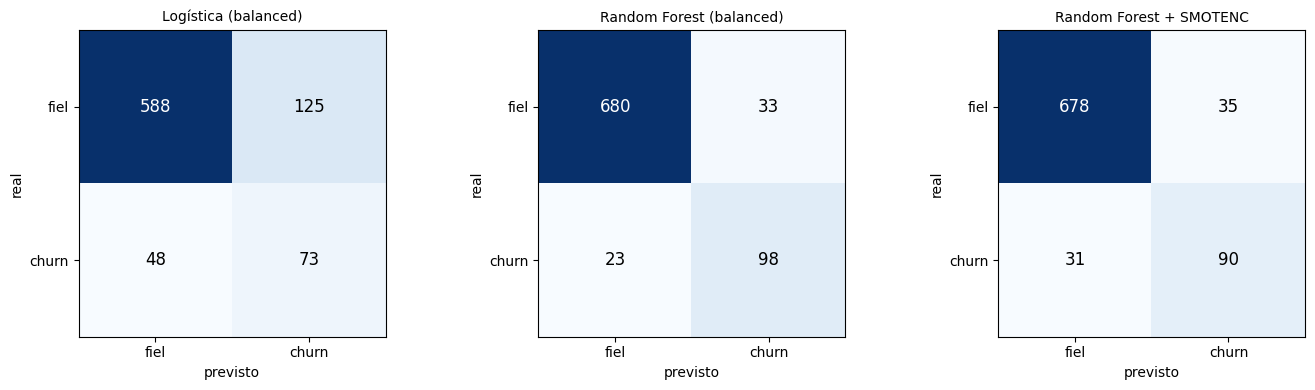

In [34]:
# Matrizes de confusão dos três modelos (no limiar ótimo de cada um)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    p = proba_teste(modelo)
    cm = confusion_matrix(y_te, (p >= limiares[nome]).astype(int))
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set_title(nome, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["fiel", "churn"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["fiel", "churn"])
    ax.set_xlabel("previsto"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()


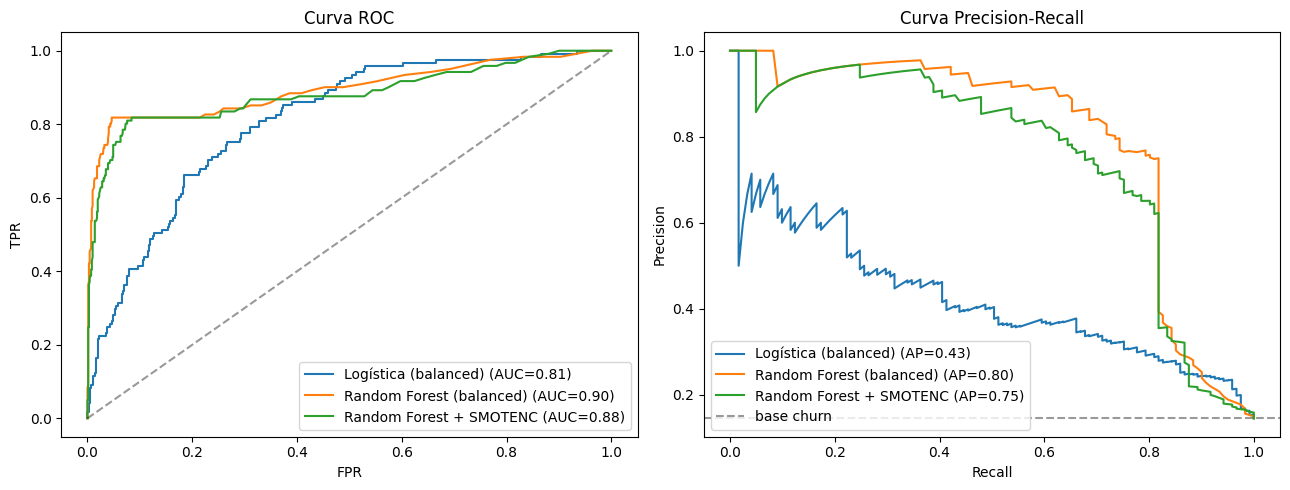

In [35]:
# Curvas ROC e Precision-Recall (independentes do limiar)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for nome, modelo in modelos.items():
    p = proba_teste(modelo)
    fpr, tpr, _ = roc_curve(y_te, p)
    ax1.plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_te, p):.2f})")
    prec, rec, _ = precision_recall_curve(y_te, p)
    ax2.plot(rec, prec, label=f"{nome} (AP={average_precision_score(y_te, p):.2f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_title("Curva ROC"); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR"); ax1.legend()
ax2.axhline(y_te.mean(), color="k", ls="--", alpha=0.4, label="base churn")
ax2.set_title("Curva Precision-Recall"); ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision"); ax2.legend()
plt.tight_layout(); plt.show()


**Leitura da avaliação:** o *baseline* tem recall 0 — inútil para reter clientes. Entre os
três modelos, a **Logística balanceada** tende a um **recall** alto na validação cruzada (boa
para *triagem*, ao custo de mais alarmes falsos), enquanto a **Random Forest** (balanceada e
com SMOTENC) lidera em **ROC-AUC/PR-AUC** e em **F1** no limiar escolhido (compare as tabelas
`cv_resultados` e `resultados` acima). A escolha do limiar materializa o **trade-off** entre **falso negativo**
(perder um cliente que cancelaria) e **falso positivo** (acionar retenção para quem não
cancelaria): limiares menores aumentam o recall e os falsos positivos; maiores, o contrário.
A decisão final depende do custo relativo de cada erro para a campanha de retenção.


## M.6 — Interpretação: por que cada cliente tende ao churn

Aqui fechamos o ciclo: ligamos os **testes de hipótese** ao **modelo**. Usamos dois ângulos,
ambos ajustados **no treino**:

1. **Odds ratios** de uma regressão logística (`statsmodels`) sobre as variáveis-chave, com
   p-valores — quanto cada fator **multiplica a chance** de churn;
2. **Importância de variáveis** da Random Forest.


In [36]:
# Regressão logística interpretável (statsmodels), variáveis padronizadas, AJUSTADA NO TREINO.
# Nomes de coluna em inglês, conforme o dataset.
chaves_tr = pd.DataFrame({
    "international plan":      (df_tr["international plan"] == "yes").astype(int),
    "voice mail plan":        (df_tr["voice mail plan"] == "yes").astype(int),
    "customer service calls": df_tr["customer service calls"],
    "total day minutes":      df_tr["total day minutes"],
    "total eve minutes":      df_tr["total eve minutes"],
}).reset_index(drop=True)

chaves_z = (chaves_tr - chaves_tr.mean()) / chaves_tr.std()
y_logit = df_tr["churn"].astype(int).reset_index(drop=True)

logit = sm.Logit(y_logit, sm.add_constant(chaves_z)).fit(disp=0)
interpretacao = pd.DataFrame({
    "odds_ratio": np.exp(logit.params),
    "p_valor": logit.pvalues,
}).round(4)
print_resultado("Regressão logística interpretável (statsmodels, treino)",
                metricas={"Pseudo R² (McFadden)": f"{logit.prsquared:.4f}"})
interpretacao


Regressão logística interpretável (statsmodels, treino)
  Pseudo R² (McFadden) = 0.2022



,odds_ratio,p_valor
const,0.10,0.00
international plan,1.81,0.00
voice mail plan,0.65,0.00
customer service calls,2.02,0.00
total day minutes,1.89,0.00
total eve minutes,1.40,0.00


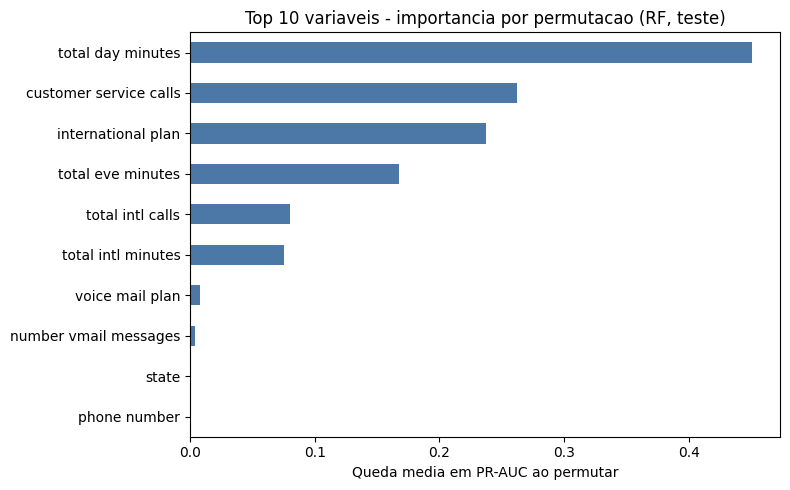

In [37]:
# Importancia por PERMUTACAO (no teste held-out), robusta ao vies de cardinalidade da
# importancia por impureza. Permuta as colunas ORIGINAIS -> atribuicao por variavel real.
rf_pipe = modelos["Random Forest (balanced)"]
perm = permutation_importance(
    rf_pipe, df_te, y_te, scoring="average_precision",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
imp = (
    pd.Series(perm.importances_mean, index=df_te.columns)
    .sort_values(ascending=False)
    .head(10)
)
ax = imp[::-1].plot(kind="barh", color="#4C78A8", figsize=(8, 5))
ax.set_title("Top 10 variaveis - importancia por permutacao (RF, teste)")
ax.set_xlabel("Queda media em PR-AUC ao permutar")
plt.tight_layout(); plt.show()

**Interpretação (odds ratios padronizados):** na tabela `interpretacao` acima, cada
`odds_ratio` indica quanto o fator **multiplica a chance** de churn por desvio-padrão (valores
> 1 elevam o risco; < 1 protegem), com o respectivo `p_valor`:

- **`total day minutes`** e **`customer service calls`** elevam a chance de churn — confirmam **H2 e H1**;
- **`international plan`** eleva a chance — confirma **H3**;
- **`voice mail plan`** é **protetor** (odds ratio < 1).

A importância da Random Forest concorda com os testes: `total day minutes`,
`customer service calls` e `international plan` aparecem no topo. Ou seja, **o modelo aprende
exatamente os fatores que os testes de hipótese apontaram** — a originalidade da etapa M se
materializa nessa coerência entre estatística inferencial e modelo preditivo.


## M.7 — Conclusões da modelagem

- **H1, H2 e H3 confirmadas** por testes formais no treino (p ≪ 0,05); **H4 (estado)** tem
  sinal fraco e instável, não sendo um *driver* central — daí a decisão sobre os *dummies* de
  `state` ter sido tomada por validação cruzada (ver M.2).
- A **seleção de variáveis é informada pelos testes** (M.1 → M.2) e **validada por CV**:
  descartar as variáveis sem sinal (`account length` e as contagens de ligações `*calls`)
  e as cobranças redundantes não prejudica as métricas e simplifica o modelo; `area code`
  também é descartado (efeito ≈ 0 em M.1), deixando `X` com apenas **8 features**.
- O **baseline** é inútil para o objetivo (recall 0). Tratar o desbalanceamento é essencial.
- Na **validação cruzada** (média ± desvio) e na **avaliação** **held-out**, a **Random Forest**
  (balanceada e com SMOTENC) lidera em poder de ranqueamento (ROC-AUC/PR-AUC) e em F1 no limiar
  escolhido, enquanto a **Logística** é a mais interpretável e a de maior recall. O **limiar**
  foi escolhido por F1 (via CV), não fixado em 0,5.
- A **interpretação** (odds ratios + importância) bate com os testes: uso diurno, contato com
  atendimento e plano internacional elevam o churn; voice mail protege.
- **Recomendação de uso:** para uma campanha de retenção, priorizar os clientes com maior
  probabilidade prevista pela Random Forest, ajustando o limiar conforme o orçamento da ação.

Esses resultados alimentam diretamente a etapa **C — Communicate**, onde os achados serão
comunicados de forma visual e acessível.


# C — Communicate and Visualize the Results

Esta etapa fecha o ciclo AGEMC. Seu papel é transformar os resultados técnicos das etapas anteriores — hipóteses testadas, decisões de modelagem, métricas e interpretação — em uma comunicação clara, visual e acessível, capaz de ser entendida por qualquer pessoa, com ou sem formação técnica.

**Estrutura da seção C:**
- **C.1** — A jornada: narrativa completa do projeto em linguagem acessível.
- **C.2** — Os fatores de risco: painel visual dos quatro principais preditores de churn.
- **C.3** — Desempenho dos modelos: comparação e matriz de confusão do modelo escolhido.
- **C.4** — Usando o modelo na prática: curva de ganho e distribuição de probabilidades.
- **C.5** — Nosso projeto vs. o Projeto FMF: comparação metodológica.

## C.1 — A jornada: da pergunta ao modelo

### O problema

A SyriaTel, uma operadora de telecomunicações, tem um desafio crítico: cerca de **1 em cada 7 clientes cancela o serviço** (*churn*). Adquirir um novo cliente custa muito mais do que reter um existente — mas a retenção reativa chega tarde demais. A pergunta que motivou este projeto foi:

> **É possível identificar, com antecedência, quais clientes têm maior risco de cancelar — antes que o cancelamento aconteça?**

### Os dados

Trabalhamos com **3.333 clientes** descritos por 21 características: uso de ligações por período do dia, planos contratados, número de chamadas ao atendimento e o desfecho final. Os dados estavam limpos — sem valores ausentes nem duplicatas. O principal desafio foi o **desequilíbrio**: 85,5% dos clientes não cancelaram e apenas 14,5% cancelaram. Um modelo ingênuo que sempre dissesse "não vai cancelar" teria 85,5% de acurácia e seria completamente inútil.

### O que a análise revelou

Antes de construir qualquer modelo, testamos formalmente quatro hipóteses usando os testes estatísticos adequados para cada tipo de dado — qui-quadrado para variáveis categóricas, Mann-Whitney U para variáveis numéricas sem distribuição normal:

| Hipótese | Resultado | Efeito |
|---|---|---|
| **H1:** ≥ 4 chamadas ao atendimento → mais churn | **Confirmada** | Forte (Cramér's V = 0,33) |
| **H2:** alto uso diurno → mais churn | **Confirmada** | Moderado (r = 0,19) |
| **H3:** plano internacional → mais churn | **Confirmada** | Forte (Cramér's V = 0,26) |
| **H4:** estado (localização) → mais churn | Confirmada, mas efeito **fraco** | Pequeno (V = 0,17) — descartado no modelo |

O **plano de voice mail** surgiu como fator surpresa: clientes com esse plano cancelam **menos** (fator protetor).

### A originalidade: estatística e modelo juntos

Em vez de ir direto ao modelo de machine learning — como faz o Projeto FMF de referência — nosso grupo usou os resultados dos testes para **decidir quais variáveis entrariam no modelo**. Variáveis sem sinal estatístico foram descartadas; as com sinal forte foram mantidas. O modelo foi treinado sobre esse conjunto enxuto de **8 features** (de dezenas possíveis), com todo o processo anti-vazamento: split antes de qualquer análise, encoding e balanceamento dentro dos pipelines de validação cruzada.

Quando o modelo foi treinado e perguntamos a ele quais variáveis mais influenciaram suas previsões, as respostas foram as mesmas que os testes apontaram. Isso não é coincidência — é coerência metodológica.

### O modelo escolhido

A **Random Forest balanceada** foi o melhor modelo, avaliado em dados que nunca viu durante o treinamento:

- **Recall de 81%:** captura 4 de cada 5 clientes que cancelariam.
- **Precisão de 75%:** de cada 4 alertas, pelo menos 3 são cancelamentos reais.
- **ROC-AUC de 0,90:** ranqueia muito bem os clientes por risco.

Isso é muito superior ao *baseline* (que nunca alerta ninguém e, portanto, perde 100% dos churners).

## C.2 — Os fatores que movem o churn

Os testes de hipótese da etapa M confirmaram quatro fatores com associação estatisticamente significativa ao churn. O painel abaixo mostra cada um em termos diretos — taxas de cancelamento e comparações visuais que permitem entender a magnitude de cada efeito.

**Leitura do painel:**
- **Plano internacional (H3):** o sinal mais dramático. Clientes com esse plano cancelam a taxas **3,7× maiores** que os demais.
- **Chamadas ao atendimento (H1):** a taxa de churn é estável em ~10% até 3 chamadas, depois dispara a partir de 4. É um gatilho de alerta claro e acionável. As barras laranjas indicam o grupo de risco.
- **Minutos diurnos (H2):** clientes que cancelaram usam, em média, **18% mais minutos** em ligações diurnas — as mais caras. Os losangos indicam as médias de cada grupo.
- **Voice mail (fator protetor):** único fator que **reduz** o risco. Clientes com esse plano cancelam à metade da taxa dos sem ele.

In [ ]:
# C.2 — Painel dos quatro fatores principais de churn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Os quatro fatores que mais influenciam o cancelamento (churn)",
             fontsize=15, fontweight="bold", y=1.01)

_media_geral = df["churn"].mean() * 100

# --- 1. Plano internacional ---
ax1 = axes[0, 0]
intl = churn_rate_by("international plan").set_index("international plan")
_cors1 = ["#4C78A8", "#F58518"]
_bars1 = ax1.bar(["Sem plano\ninternacional", "Com plano\ninternacional"],
                  intl["taxa_churn_pct"], color=_cors1, width=0.5)
ax1.axhline(_media_geral, color="#E45756", linestyle="--", linewidth=1.5,
             alpha=0.8, label=f"Média geral ({_media_geral:.1f}%)")
ax1.set_title("Plano internacional", fontweight="bold", fontsize=12)
ax1.set_ylabel("Taxa de churn (%)")
ax1.set_ylim(0, 55)
for bar, v in zip(_bars1, intl["taxa_churn_pct"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 1.2,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# --- 2. Chamadas ao atendimento ---
ax2 = axes[0, 1]
csc = churn_rate_by("customer service calls")
csc_plot = csc[csc["clientes"] >= 10].copy()
_cors2 = ["#F58518" if v >= 4 else "#4C78A8" for v in csc_plot["customer service calls"]]
ax2.bar(csc_plot["customer service calls"], csc_plot["taxa_churn_pct"], color=_cors2, width=0.7)
ax2.axvline(3.5, color="#E45756", linestyle="--", linewidth=1.8,
             label="Limiar crítico: ≥ 4 chamadas", alpha=0.85)
ax2.axhline(_media_geral, color="gray", linestyle=":", linewidth=1.3, alpha=0.7,
             label=f"Média geral ({_media_geral:.1f}%)")
ax2.set_title("Chamadas ao atendimento", fontweight="bold", fontsize=12)
ax2.set_ylabel("Taxa de churn (%)")
ax2.set_xlabel("Número de chamadas ao atendimento")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(csc_plot["customer service calls"])

# --- 3. Minutos diurnos: churn vs. não-churn ---
ax3 = axes[1, 0]
_day_fiel  = df.loc[~df["churn"], "total day minutes"]
_day_churn = df.loc[ df["churn"], "total day minutes"]
_bp = ax3.boxplot([_day_fiel, _day_churn],
                   labels=["Não cancelou", "Cancelou"],
                   patch_artist=True, widths=0.45,
                   boxprops=dict(facecolor="#EAF2FB", linewidth=1.5),
                   medianprops=dict(color="#E45756", linewidth=2.5),
                   whiskerprops=dict(linewidth=1.3),
                   flierprops=dict(marker="o", markersize=3, alpha=0.3))
_bp["boxes"][1].set_facecolor("#FEF3E2")
for grupo_i, (dados, cor) in enumerate(
        zip([_day_fiel, _day_churn], ["#4C78A8", "#F58518"]), 1):
    ax3.scatter(grupo_i, dados.mean(), color=cor, zorder=5, s=80,
                marker="D", label=f"{'Fiel' if grupo_i==1 else 'Churn'}: média {dados.mean():.0f} min")
ax3.set_title("Minutos diurnos", fontweight="bold", fontsize=12)
ax3.set_ylabel("Total de minutos diurnos")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)

# --- 4. Plano de voice mail ---
ax4 = axes[1, 1]
vmail = churn_rate_by("voice mail plan").set_index("voice mail plan")
_bars4 = ax4.bar(["Sem voice mail", "Com voice mail"],
                  vmail["taxa_churn_pct"], color=["#F58518", "#54A24B"], width=0.5)
ax4.axhline(_media_geral, color="#E45756", linestyle="--", linewidth=1.5,
             alpha=0.8, label=f"Média geral ({_media_geral:.1f}%)")
ax4.set_title("Plano de voice mail (fator protetor)", fontweight="bold", fontsize=12)
ax4.set_ylabel("Taxa de churn (%)")
ax4.set_ylim(0, 25)
for bar, v in zip(_bars4, vmail["taxa_churn_pct"]):
    ax4.text(bar.get_x() + bar.get_width() / 2, v + 0.4,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=13, fontweight="bold")
ax4.legend(fontsize=9)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## C.3 — Quanto o modelo acerta

Testamos três abordagens e avaliamos todas em dados **que nunca viram durante o treinamento** (conjunto de teste *held-out*). O ponto de partida é sempre o *baseline*: um modelo que simplesmente nunca alerta ninguém. Ele tem acurácia de 85,5% — mas **recall zero**. Ou seja, não identifica nenhum cliente em risco. É o piso que qualquer modelo precisa superar.

A **comparação de métricas** (à esquerda) mostra que a Random Forest balanceada lidera em todas as dimensões relevantes. As métricas usadas:
- **Recall:** dos clientes que realmente cancelaram, quantos o modelo identificou? (foco em não perder churners)
- **Precisão:** dos alertas emitidos, quantos eram cancelamentos reais? (foco em não desperdiçar ações de retenção)
- **F1:** média harmônica entre recall e precisão — equilibra os dois.
- **ROC-AUC / PR-AUC:** independentes do limiar, medem o poder de ranqueamento do modelo.

A **matriz de confusão** (à direita) traduz o desempenho para termos absolutos: quantos clientes foram corretamente identificados como churners, quantos passaram despercebidos e quantos alarmes foram falsos.

In [ ]:
# C.3 — Comparação de desempenho e matriz de confusão do melhor modelo
_metricas_plot = ["recall", "precision", "f1", "ROC_AUC", "PR_AUC"]
_rotulos = ["Recall", "Precisão", "F1", "ROC-AUC", "PR-AUC"]
_nomes = list(resultados.index)
_cores_mod = ["#4C78A8", "#F58518", "#54A24B"]
_width = 0.22
_x = np.arange(len(_metricas_plot))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Desempenho dos modelos no conjunto de teste", fontsize=14, fontweight="bold")

# --- Comparação de métricas ---
ax1 = axes[0]
for i, (nome, cor) in enumerate(zip(_nomes, _cores_mod)):
    vals = [resultados.loc[nome, m] for m in _metricas_plot]
    offset = (i - 1) * _width
    bars = ax1.bar(_x + offset, vals, _width, label=nome.replace(" (balanced)", ""), color=cor, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=7.5, color="dimgray")

ax1.axhline(0.855, color="gray", linestyle=":", alpha=0.55, linewidth=1.5,
            label="baseline: acurácia (recall = 0)")
ax1.set_xticks(_x)
ax1.set_xticklabels(_rotulos, fontsize=10)
ax1.set_ylim(0, 1.12)
ax1.set_ylabel("Valor da métrica")
ax1.set_title("Comparação entre modelos\n(limiar ótimo por F1, no teste held-out)", fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

# --- Matriz de confusão da Random Forest balanceada ---
ax2 = axes[1]
_rf_proba = modelos["Random Forest (balanced)"].predict_proba(df_te)[:, 1]
_pred_rf = (_rf_proba >= limiares["Random Forest (balanced)"]).astype(int)
_cm = confusion_matrix(y_te, _pred_rf)
_total = _cm.sum()

im = ax2.imshow(_cm, cmap="Blues", vmin=0, vmax=_cm.max())
_cell_labels = [
    ["Verdadeiro Negativo\n(VN)", "Falso Positivo\n(FP)"],
    ["Falso Negativo\n(FN)", "Verdadeiro Positivo\n(VP)"],
]
for (i, j), v in np.ndenumerate(_cm):
    _pct = v / _total * 100
    _cor_txt = "white" if v > _cm.max() * 0.55 else "black"
    _bold = "bold" if i == j else "normal"
    ax2.text(j, i, f"{_cell_labels[i][j]}\n\n{v} clientes\n({_pct:.1f}%)",
             ha="center", va="center", color=_cor_txt, fontsize=10, fontweight=_bold)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Previsto: Fiel", "Previsto: Churn"], fontsize=10)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Real: Fiel", "Real: Churn"], fontsize=10)
ax2.set_title(f"Random Forest balanceada — limiar {limiares['Random Forest (balanced)']:.2f}\n(conjunto de teste: 834 clientes)",
              fontweight="bold")

plt.tight_layout()
plt.show()

# Leitura direta da matriz
_vp = _cm[1, 1]; _fn = _cm[1, 0]; _fp = _cm[0, 1]; _vn = _cm[0, 0]
print(f"De {_vp + _fn} clientes que realmente cancelaram:")
print(f"  ✓ {_vp} foram identificados corretamente (recall = {_vp/(_vp+_fn):.0%})")
print(f"  ✗ {_fn} passaram despercebidos (falsos negativos)")
print(f"\nDe {_vp + _fp} alertas emitidos pelo modelo:")
print(f"  ✓ {_vp} eram cancelamentos reais (precisão = {_vp/(_vp+_fp):.0%})")
print(f"  ✗ {_fp} eram clientes que não cancelariam (falsos positivos)")

## C.4 — Usando o modelo na prática

Na prática, o modelo atribui a cada cliente ativo uma **probabilidade de churn** entre 0 e 1. A equipe de retenção pode ordenar todos os clientes por essa probabilidade e concentrar esforços nos de maior risco — sem precisar acionar toda a base.

**A curva de ganho** (à esquerda) mostra o poder desse ranqueamento: acionando apenas os 20% de maior risco, capturamos muito mais churners do que se agíssemos aleatoriamente. A linha laranja representa o modelo; a diagonal tracejada preta representa uma abordagem sem nenhum modelo (acaso).

**A distribuição de probabilidades** (à direita) mostra como o modelo separa os dois grupos: a maior parte dos clientes fiéis recebe probabilidades baixas (azul concentrado à esquerda), e a maior parte dos churners recebe probabilidades altas (laranja concentrado à direita). O limiar vermelho tracejado é o ponto de decisão escolhido por validação cruzada.

In [ ]:
# C.4 — Curva de ganho e distribuição de probabilidades
p_rf_te = modelos["Random Forest (balanced)"].predict_proba(df_te)[:, 1]

df_risco = (
    pd.DataFrame({"prob_churn": p_rf_te, "churn_real": y_te.values})
    .sort_values("prob_churn", ascending=False)
    .reset_index(drop=True)
)
df_risco["churners_capturados"] = df_risco["churn_real"].cumsum()
df_risco["cobertura_churn_pct"] = df_risco["churners_capturados"] / df_risco["churn_real"].sum() * 100
df_risco["pct_clientes_acionados"] = (df_risco.index + 1) / len(df_risco) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Usando o modelo na prática", fontsize=14, fontweight="bold")

# --- Curva de ganho ---
ax1 = axes[0]
ax1.plot(df_risco["pct_clientes_acionados"], df_risco["cobertura_churn_pct"],
         color="#F58518", linewidth=2.5, label="Random Forest balanceada")
ax1.plot([0, 100], [0, 100], "k--", alpha=0.4, label="acaso (sem modelo)")
ax1.fill_between(df_risco["pct_clientes_acionados"], df_risco["cobertura_churn_pct"],
                 alpha=0.12, color="#F58518")

_marcadores = [(20, "#E45756", "-"), (30, "#54A24B", "--")]
for pct_ac, cor, ls in _marcadores:
    idx = min(int(pct_ac / 100 * len(df_risco)) - 1, len(df_risco) - 1)
    cob = df_risco.loc[idx, "cobertura_churn_pct"]
    ax1.axvline(pct_ac, color=cor, linestyle=ls, alpha=0.75,
                label=f"Top {pct_ac}% → captura {cob:.0f}% dos churners")
    ax1.scatter(pct_ac, cob, color=cor, s=90, zorder=5)

ax1.set_xlabel("% de clientes acionados (do maior para o menor risco)")
ax1.set_ylabel("% de churners capturados")
ax1.set_title("Curva de ganho: eficiência do modelo\npara campanhas de retenção", fontweight="bold")
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)

# --- Distribuição de probabilidades ---
ax2 = axes[1]
ax2.hist(p_rf_te[y_te == 0], bins=40, alpha=0.55, color="#4C78A8",
         label="Clientes fiéis", density=True)
ax2.hist(p_rf_te[y_te == 1], bins=40, alpha=0.70, color="#F58518",
         label="Clientes que cancelaram", density=True)
thr_rf = limiares["Random Forest (balanced)"]
ax2.axvline(thr_rf, color="#E45756", linewidth=2.2,
            label=f"Limiar de decisão ({thr_rf:.2f})")
ax2.set_xlabel("Probabilidade de churn prevista pelo modelo")
ax2.set_ylabel("Densidade")
ax2.set_title("Distribuição das probabilidades previstas\n(conjunto de teste)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumo quantitativo
total_churn_te = int(y_te.sum())
print("Resumo — cobertura de churners por fatia de clientes acionados:")
print(f"{'Fatia':>20} | {'Clientes':>10} | {'Churners capturados':>22} | {'Cobertura':>10}")
print("-" * 70)
for pct in [10, 20, 30, 50]:
    n = int(pct / 100 * len(df_risco))
    cap = int(df_risco.iloc[:n]["churn_real"].sum())
    print(f"{'Top ' + str(pct) + '%':>20} | {n:>10} | {cap:>12} de {total_churn_te:<7} | {cap/total_churn_te*100:>8.0f}%")

## C.5 — Nosso projeto vs. o Projeto FMF de referência

| Dimensão | Projeto FMF (referência) | Nosso projeto |
|---|---|---|
| **Pergunta científica** | Prever churn em telecomunicações | Mesma |
| **Dataset** | SyriaTel (3.333 clientes, 21 colunas) | Mesmo |
| **Exploração** | Análise descritiva e visual | Mesma + teste qui-quadrado para H4 |
| **Testes de hipótese formais** | Ausentes | H1–H4: qui-quadrado, Mann-Whitney U, ponto-bisserial (somente no treino) |
| **Seleção de variáveis** | Não documentada formalmente | Guiada pelos testes (M.1 → M.2), validada por CV |
| **Anti-vazamento de informação** | Não explicitado | Split antes de qualquer análise; encoding e SMOTENC dentro do pipeline |
| **Limiar de decisão** | Padrão (0,5) | Escolhido por F1 via validação cruzada no treino |
| **Interpretação** | Feature importance por impureza | Odds ratios (statsmodels) + importância por **permutação** (mais robusta) |
| **Coerência interna** | Modelo separado da análise | Testes, seleção e modelo se reforçam mutuamente |

**Leitura:** a diferença não é apenas técnica — é metodológica. Ao conectar os testes de hipótese à seleção de variáveis e ao modelo final, cada decisão do pipeline tem justificativa estatística. O modelo aprendeu exatamente o que os testes indicaram como relevante, e o resultado disso é visível na coerência entre odds ratios, importância por permutação e os tamanhos de efeito dos testes de M.1.

**Conclusão do projeto:** é possível prever o churn de clientes de telecomunicações antes que ele aconteça, com qualidade suficiente para campanhas de retenção reais. Os três fatores mais importantes são (1) chamadas ao atendimento ≥ 4, (2) plano internacional e (3) alto uso diurno. O plano de voice mail é o principal fator protetor. A Random Forest balanceada — com recall 0,81, F1 0,78 e ROC-AUC 0,90 no teste — é o modelo recomendado para uso em produção, com o limiar ajustável conforme o orçamento de retenção disponível.